
# Paso 00b — Grunnkretser como alternativa al radio de captación fijo

El radio de 1000 m (Tarea 1) trata a los 4 nodos igual, pero no lo son: para
Laksevåg el círculo capta bastante agua/vegetación (celdas SSB vacías o casi),
mientras que para Bryggen (denso, urbano) el mismo radio concentra
desproporcionadamente la masa — de ahí que Bryggen salga con ~90% de la
población en algunas lecturas rápidas, un artefacto de la forma del círculo,
no necesariamente de la realidad.

**Alternativa:** usar las **grunnkretser** (la unidad estadística pequeña real
de SSB/Kartverket, ~403 en Bergen+Askøy) y elegir a mano qué zonas le
corresponden a cada nodo — respeta la geografía real (costa, barrios) en vez
de un círculo arbitrario.

Este notebook **no decide nada todavía**: descarga las grunnkretser, las
recorta a la zona de estudio, y genera los mapas + la tabla de referencia para
que la elección de zonas por nodo se haga a mano, mirando el mapa.

**Fuente:** Kartverket, WFS "Statistiske enheter grunnkretser"
(CC BY 4.0) — ver `src/grunnkretser.py` para el detalle técnico (URL, capa,
CRS).


In [1]:

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import contextily as cx
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas
import grunnkretser as gk_mod

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

cfg = masas.cargar_config(CONFIG_PATH)
nodos_utm = masas.cargar_nodos(cfg, BASE_DIR)

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

COLOR_NODO = {"kleppesto": "#1f6f8b", "laksevag": "#2f7d32", "bryggen": "#c0392b", "sandviken": "#8e44ad"}


## Descargar y recortar

Se descargan (o se leen de caché) TODAS las grunnkretser de Noruega, se
filtran a Bergen (kommunenummer 4601) + Askøy (4627), y se recortan a una
ventana alrededor de los 4 nodos para el mapa.


In [2]:

gk_norge = gk_mod.descargar_grunnkretser(PROCESSED_DIR / "grunnkretser_norge.parquet")
gk_bergen_askoy = gk_mod.grunnkretser_bergen_askoy(gk_norge)
print(f"Grunnkretser en Noruega: {len(gk_norge):,}")
print(f"Grunnkretser en Bergen (4601) + Askøy (4627): {len(gk_bergen_askoy)}")

MARGEN_MAPA_M = 2000
bbox_mapa = masas.bbox_bergen_askoy(nodos_utm, MARGEN_MAPA_M)
xmin, ymin, xmax, ymax = bbox_mapa
gk_zona = gk_mod.grunnkretser_bergen_askoy(gk_norge).cx[xmin:xmax, ymin:ymax].reset_index(drop=True)
gk_zona = gk_mod.nodo_mas_cercano(gk_zona, nodos_utm)
print(f"Grunnkretser en la ventana del mapa (margen {MARGEN_MAPA_M} m): {len(gk_zona)}")


Grunnkretser en Noruega: 14,126
Grunnkretser en Bergen (4601) + Askøy (4627): 403
Grunnkretser en la ventana del mapa (margen 2000 m): 158


In [3]:

tabla_referencia = gk_zona[[
    "grunnkretsnummer", "grunnkretsnavn", "kommunenummer", "nodo_mas_cercano", "distancia_nodo_mas_cercano_m",
]].sort_values(["nodo_mas_cercano", "distancia_nodo_mas_cercano_m"]).reset_index(drop=True)
tabla_referencia["distancia_nodo_mas_cercano_m"] = tabla_referencia["distancia_nodo_mas_cercano_m"].round(0)
tabla_referencia.to_csv(OUTPUT_DIR / "grunnkretser_tabla_referencia.csv", index=False)
print("Guardado:", OUTPUT_DIR / "grunnkretser_tabla_referencia.csv")
tabla_referencia


Guardado: c:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\demand\output\grunnkretser_tabla_referencia.csv


,grunnkretsnummer,grunnkretsnavn,kommunenummer,nodo_mas_cercano,distancia_nodo_mas_cercano_m
0,46010115,Strandkaien,4601,bryggen,44.0
1,46010106,Klosteret,4601,bryggen,238.0
2,46010116,Torget,4601,bryggen,281.0
3,46010147,Kalmaren,4601,bryggen,291.0
4,46010117,Vetrlidsallmenningen,4601,bryggen,296.0
...,...,...,...,...,...
153,46010601,Lønborg,4601,sandviken,2306.0
154,46010637,Sandviksfjellet,4601,sandviken,2326.0
155,46010708,Ervik,4601,sandviken,3232.0
156,46010707,Selvik,4601,sandviken,3540.0


## Mapa general — las grunnkretser de la zona, coloreadas por nodo más cercano

Solo de referencia visual (agrupación por cercanía, NO es la asignación final
— la decisión de qué zonas van con cada nodo se toma a mano).


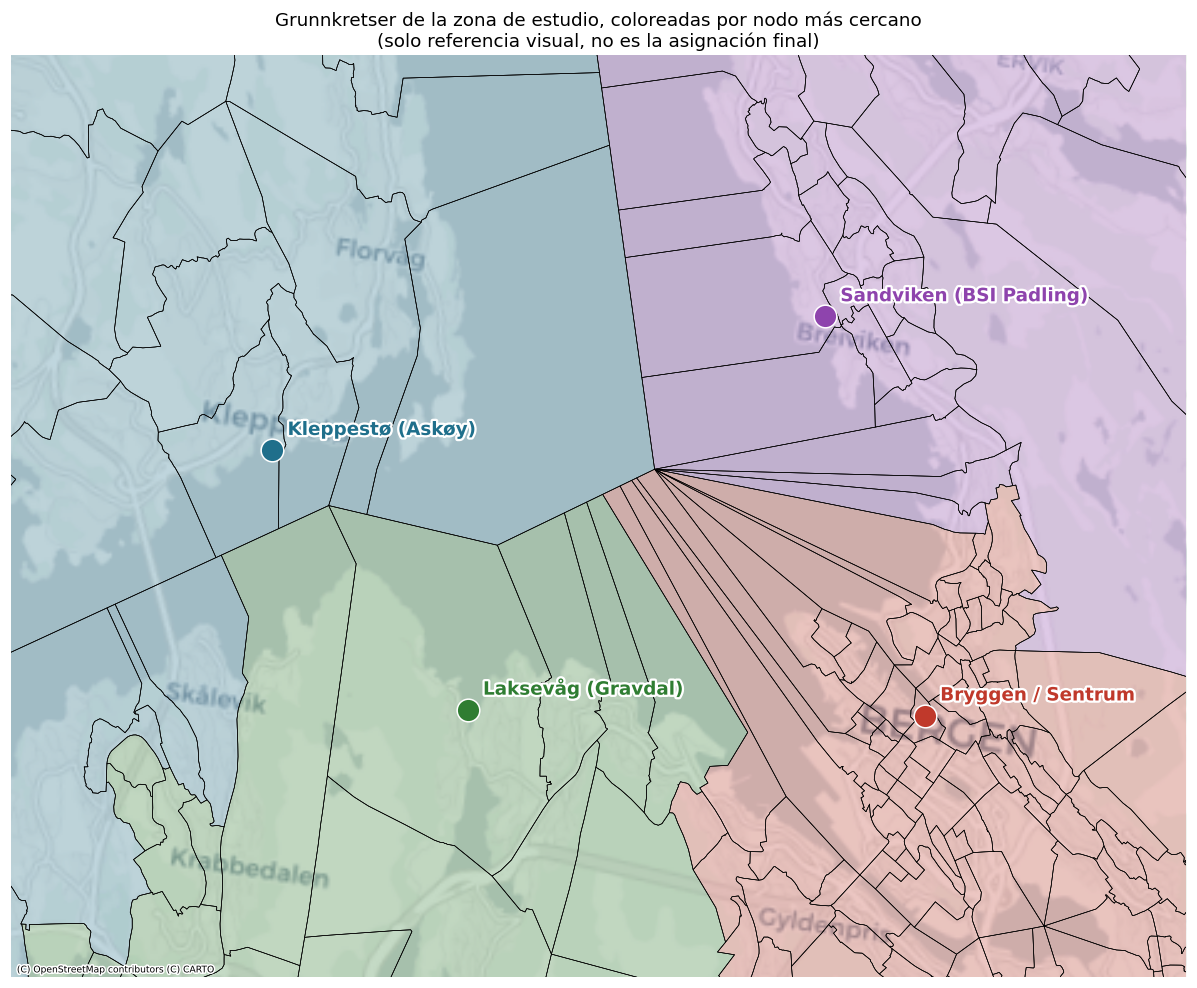

In [4]:

fig, ax = plt.subplots(figsize=(11, 10))

for nid, color in COLOR_NODO.items():
    sub = gk_zona[gk_zona["nodo_mas_cercano"] == nid]
    sub.plot(ax=ax, facecolor=color, edgecolor="black", linewidth=0.4, alpha=0.28, zorder=2)

gk_zona.boundary.plot(ax=ax, color="black", linewidth=0.4, zorder=3)

for nid, row in nodos_utm.iterrows():
    ax.scatter([row.geometry.x], [row.geometry.y], color=COLOR_NODO[nid], edgecolor="white", s=220, zorder=5)
    ax.annotate(
        row["nombre"], xy=(row.geometry.x, row.geometry.y), xytext=(10, 10), textcoords="offset points",
        fontsize=12, fontweight="bold", color=COLOR_NODO[nid], zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs="EPSG:32633", attribution_size=6)
ax.set_axis_off()
ax.set_title("Grunnkretser de la zona de estudio, coloreadas por nodo más cercano\n(solo referencia visual, no es la asignación final)", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "grunnkretser_mapa_general.png", dpi=180, bbox_inches="tight")
plt.show()


## Mapas por nodo, con el nombre de cada grunnkrets

Zoom más cerrado alrededor de cada nodo (radio de vista 1500 m) con el nombre
de cada grunnkrets visible, para elegir a mano cuáles incluir. Se dibuja
también el círculo de 1000 m (línea punteada) como referencia de comparación
contra el método anterior.


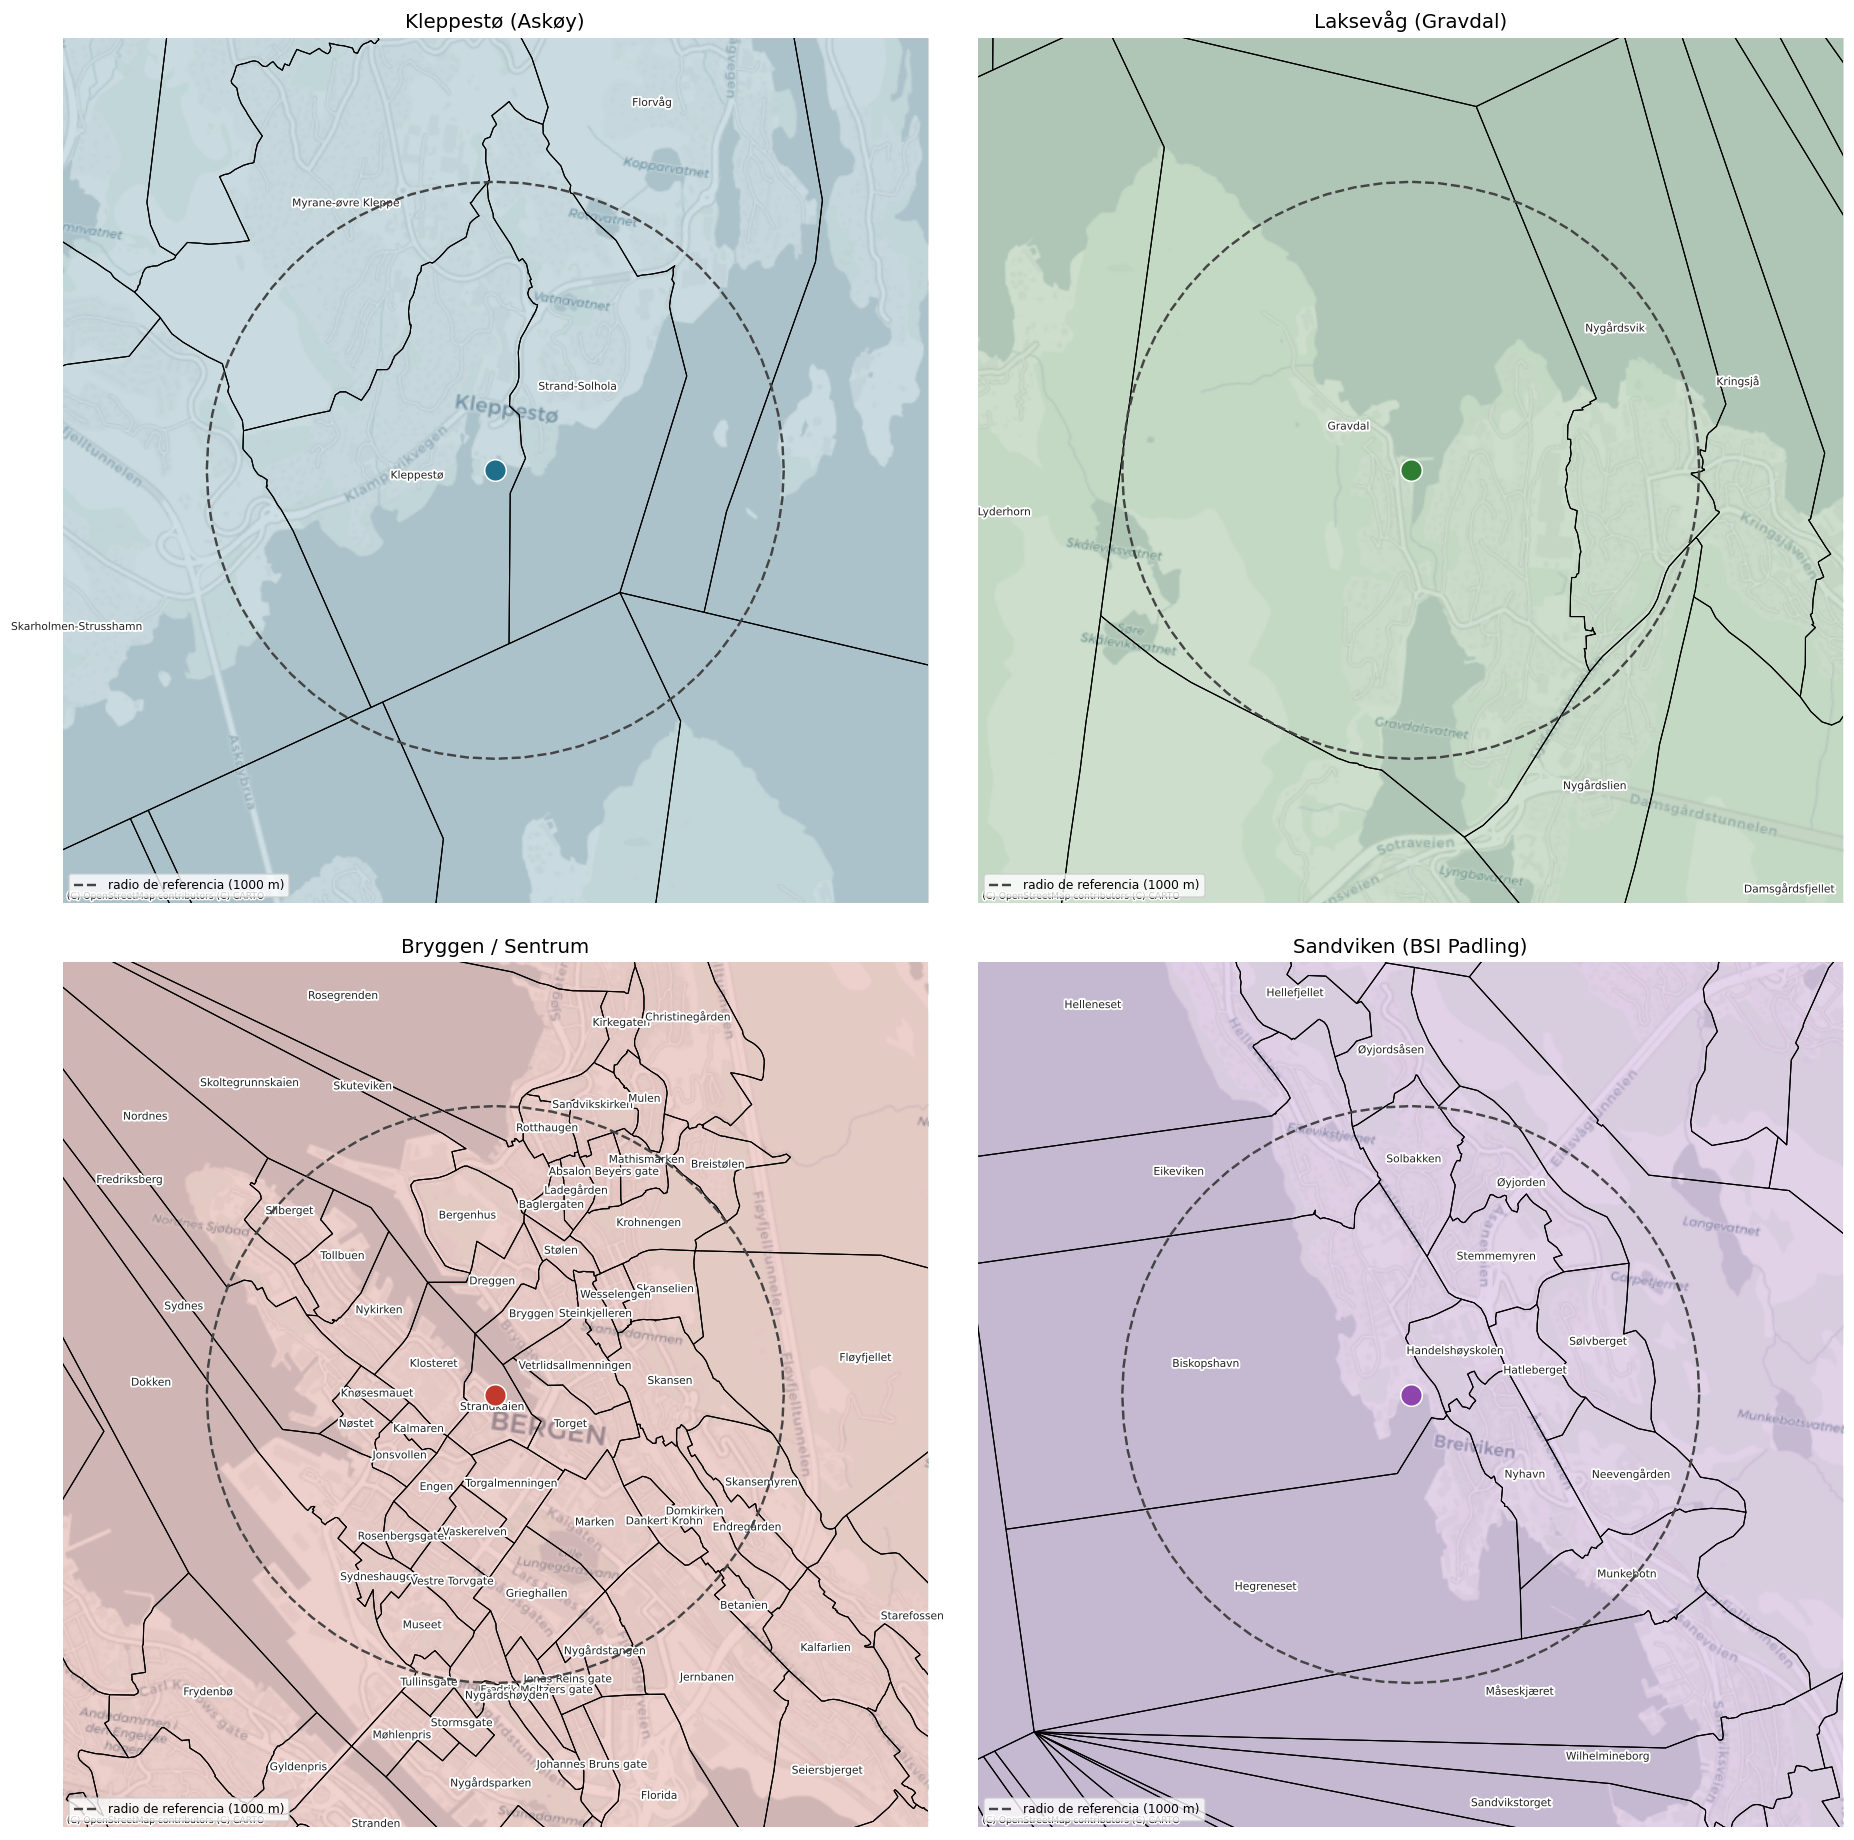

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(17, 17))

RADIO_VISTA_M = 1500
RADIO_REFERENCIA_M = cfg["captacion"]["radio_m"]

for ax, (nid, row) in zip(axes.flat, nodos_utm.iterrows()):
    centro = row.geometry
    sub = gk_bergen_askoy.cx[centro.x - RADIO_VISTA_M:centro.x + RADIO_VISTA_M, centro.y - RADIO_VISTA_M:centro.y + RADIO_VISTA_M]

    sub.plot(ax=ax, facecolor=COLOR_NODO[nid], edgecolor="black", linewidth=0.6, alpha=0.22, zorder=2)
    sub.boundary.plot(ax=ax, color="black", linewidth=0.7, zorder=3)

    for _, zrow in sub.iterrows():
        c = zrow.geometry.centroid
        ax.annotate(
            zrow["grunnkretsnavn"], xy=(c.x, c.y), ha="center", va="center", fontsize=7,
            color="#222222", zorder=4, path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        )

    circulo = centro.buffer(RADIO_REFERENCIA_M)
    cx_, cy_ = circulo.exterior.xy
    ax.plot(cx_, cy_, color="#444444", linewidth=1.6, linestyle="--", zorder=5, label=f"radio de referencia ({RADIO_REFERENCIA_M} m)")

    ax.scatter([centro.x], [centro.y], color=COLOR_NODO[nid], edgecolor="white", s=200, zorder=6)
    ax.set_xlim(centro.x - RADIO_VISTA_M, centro.x + RADIO_VISTA_M)
    ax.set_ylim(centro.y - RADIO_VISTA_M, centro.y + RADIO_VISTA_M)
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs="EPSG:32633", attribution_size=6)
    ax.set_axis_off()
    ax.set_title(row["nombre"], fontsize=13)
    ax.legend(loc="lower left", fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "grunnkretser_zoom_por_nodo.png", dpi=180, bbox_inches="tight")
plt.show()



## Siguiente paso

**Este notebook no asigna zonas todavía.** Con estos mapas y
`output/grunnkretser_tabla_referencia.csv`, hay que decidir a mano qué
grunnkretser le corresponden a cada uno de los 4 nodos (una misma grunnkrets
no debería repetirse en dos nodos). Una vez elegidas, se actualiza
`config/instance.yaml` con la lista de `grunnkretsnummer` por nodo y se
recalculan las masas de la Tarea 1 sumando población/empleo de esas zonas
exactas en vez del círculo — reemplaza la lógica de `celdas_en_radio` por una
de "celdas cuyo centro cae dentro de la UNIÓN de las grunnkretser elegidas
para ese nodo", que es un cambio pequeño en `src/masas.py`.
